# 04 · Strain across a superlattice

Data: `data/ImgOrigin.mrc`, an experimental HAADF-STEM image (Thermo Fisher MRC
export) of an oxide superlattice: bright and dark layers alternate along `y`.

This notebook computes

* the **lattice graph** shared by both methods,
* **Method 1**: out-of-plane strain against an external spacing `d0`,
* **Method 2**: the full strain and rotation tensor against a reference region,

and shows how to analyse the whole span of the interfaces.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import polarmap as pm
from polarmap import plotting

plt.rcParams["figure.dpi"] = 80
print("polarmap", pm.__version__)
plt.rcParams["figure.dpi"] = 60   # ~8000 columns: keep the notebook small

polarmap 0.1.0


## 1. Image

The file declares a Thermo Fisher extended header that is not actually present;
`polarmap` detects this and reads the image correctly (hence the warning).

image (1122, 1121), sampling 0.03274 nm/px


/tmp/ipykernel_2589/3484393210.py:1: UserWarning: ImgOrigin.mrc: header declares a 909312-byte extended header that is not present in the file; reading the image data directly after the 1024-byte main header.
  image, sampling = pm.load_image("data/ImgOrigin.mrc")


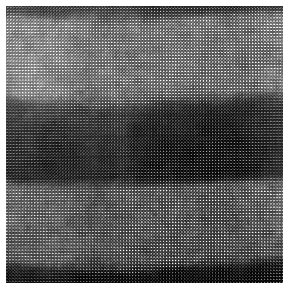

In [2]:
image, sampling = pm.load_image("data/ImgOrigin.mrc")
print(f"image {image.shape}, sampling {sampling:.5f} nm/px")
fig, ax = plt.subplots(figsize=(6, 6))
plotting.show_image(ax, image); ax.axis("off");

## 2. Columns and lattice vectors

The lattice spacing is about 0.4 nm / 0.0327 nm ≈ 12 px, so `min_distance=12`
detects the bright A-site columns only. Refining about 8000 columns takes
roughly a minute.

7935 columns;  v1 = [12.403  0.059] px,  v2 = [-0.023 12.591] px


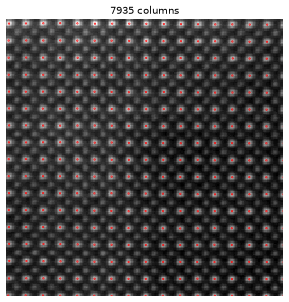

In [3]:
seeds = pm.detect_peaks(image, min_distance=12, threshold_rel=0.1, exclude_border=4)
pos, fit = pm.refine_gaussian(image, seeds, box=4, return_params=True)
pos = pos[fit["success"]]
v1, v2 = pm.estimate_lattice_vectors(pos)
print(f"{len(pos)} columns;  v1 = {np.round(v1, 3)} px,  v2 = {np.round(v2, 3)} px")
fig, ax = plt.subplots(figsize=(6, 6))
plotting.plot_columns(image, pos, ax=ax, s=3)
ax.set_xlim(400, 600); ax.set_ylim(600, 400);

## 3. The validated lattice graph

Each column is linked to its neighbours along ±v1 and ±v2; bonds that fail the
loop-closure test would be rejected before either method uses them.

In [4]:
graph = pm.build_lattice_graph(pos, v1, v2)
print(graph.report())
corner = int(np.argmin(np.hypot(*pos.T)))          # the top-left column
print(graph.describe_column(corner))

Lattice graph: 7935 columns
  bonds found: 31364 / 31740 (98.8 %)
    +v1: 7845 / 7935
    -v1: 7845 / 7935
    +v2: 7837 / 7935
    -v2: 7837 / 7935
  bonds rejected by loop closure: 0 / 31364 (0.0 %)
  columns missing >= 1 direction: 352
column 0 at (5.7, 7.1) px:
  +v1: column 1, bond length 13.35 px, used
  -v1: no neighbour inside the search window
  +v2: column 90, bond length 12.79 px, used
  -v2: no neighbour inside the search window


## 4. Method 1: strain along the growth direction against `d0`

Here `d0` is set to the bulk SrTiO₃ spacing (0.3905 nm) as an example: choose the
bulk value appropriate to your question. The result is proportional to the
pixel calibration.

In [5]:
m1 = pm.projection_strain(graph, v2, d0_px=0.3905 / sampling, image_shape=image.shape)
print(m1.report())

Projection strain (Method 1): 7935 columns
  valid: 7486 (94.3 %)
  no neighbour along the direction: 5 (0.1 %)
  bonds rejected by loop closure: 0 (0.0 %)
  within edge margin: 444 (5.6 %)
  robust outlier: 0 (0.0 %)
  strain: mean +5.47 %, std 2.25 %


## 5. Method 2: reference lattice in a dark layer

Reference lattice (Method 2)
  BFS reached 7935 / 7935 columns (100.0 %)
  reference columns used in final fit: 983 / 1229
  fit residual: mean 0.196 px, max 0.424 px
  residual with initial vectors: mean 1.421 px, max 3.281 px
  a = (12.406, 0.048) px, |a| = 12.4064 px = 0.40618 nm
  b = (-0.022, 12.262) px, |b| = 12.2620 px = 0.40145 nm


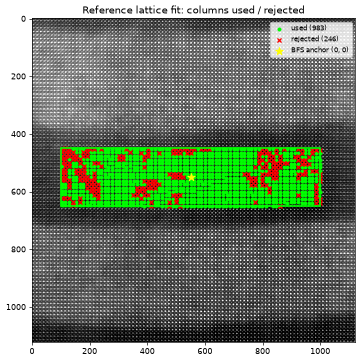

In [6]:
x_range, y_range = (100, 1000), (450, 650)          # pixels
reference = pm.fit_reference_lattice(graph, pm.in_rectangle(pos, x_range, y_range))
print(reference.report(sampling))
plotting.plot_reference_region(image, graph, reference, x_range=x_range, y_range=y_range);

In [7]:
tensor = pm.tensor_strain(graph, reference, mask=pm.inside_image(pos, image.shape, 20))
print(tensor.report())

Tensor strain (Method 2, image frame): 7486 / 7935 columns with a tensor
  exx: mean +0.00 %, std 0.88 %
  eyy: mean +2.60 %, std 2.19 %
  exy: mean +0.03 %, std 0.50 %
  omega: mean +0.022 deg, std 0.268 deg


### Tensor components

The per-column view (top) is the measurement; the interpolated view (bottom) is
for display only. Colour bars are placed under each panel.

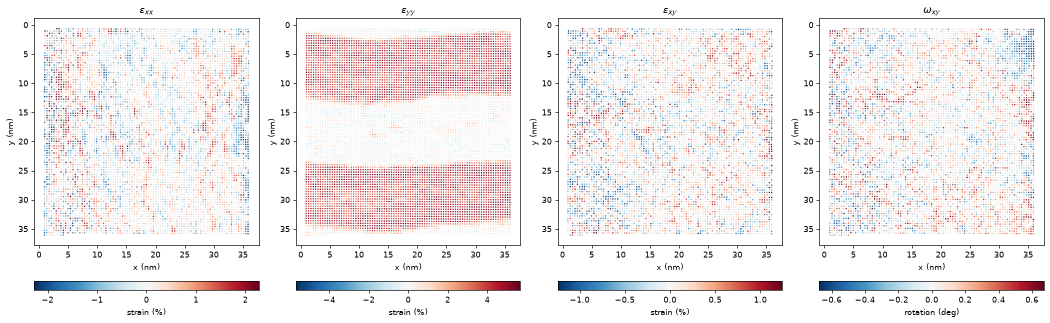

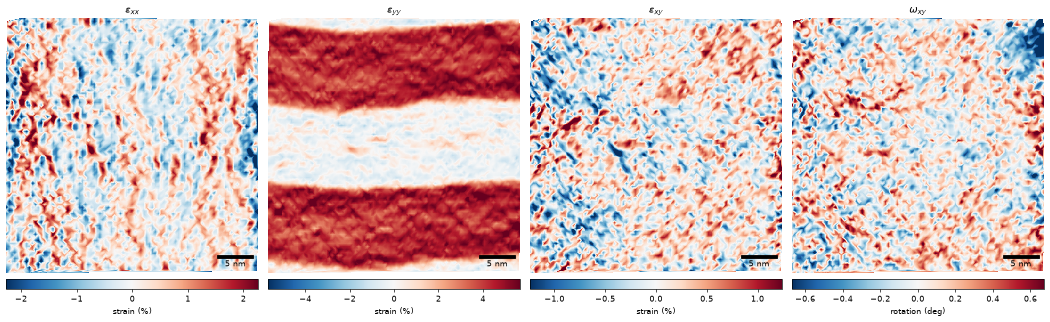

In [8]:
plotting.plot_strain_tensor(tensor, sampling=sampling, kind="scatter", s=3)
plotting.plot_strain_tensor(tensor, sampling=sampling, kind="grid", scalebar_nm="auto",
                            show_axes=False);

`eyy` alternates between about 0 (the dark reference layers) and about +4.5 %
(the bright layers), while `exx` stays close to zero everywhere: the in-plane
lattice is continuous across the interfaces (coherent growth), and the bright
layers are expanded along the growth direction. `exy` and `omega` show only
small, spatially uncorrelated fluctuations.

## 6. Method 1 vs Method 2, and layer profiles

Band-averaged profiles use the per-column values directly (the shaded band is
the standard deviation within each band of rows).

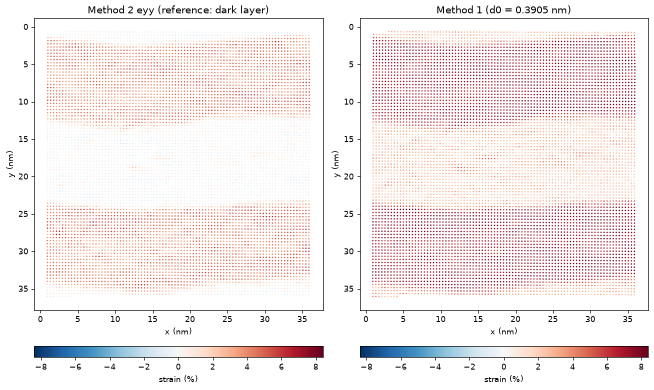

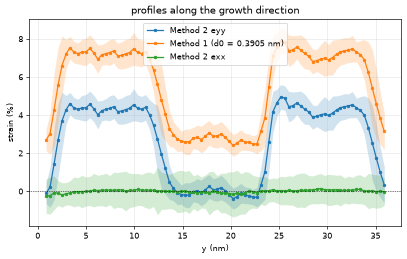

In [9]:
plotting.plot_strain_comparison(pos, tensor.eyy, m1.strain,
                                labels=("Method 2 eyy (reference: dark layer)",
                                        "Method 1 (d0 = 0.3905 nm)"),
                                sampling=sampling, s=3)
band = v2[1]                                          # one row of columns per band
profiles = {
    "Method 2 eyy": pm.binned_profile(pos, tensor.eyy, axis="y", bin_width=band),
    "Method 1 (d0 = 0.3905 nm)": pm.binned_profile(pos, m1.strain, axis="y", bin_width=band),
    "Method 2 exx": pm.binned_profile(pos, tensor.exx, axis="y", bin_width=band),
}
plotting.plot_profiles(profiles, sampling=sampling, title="profiles along the growth direction");

In [10]:
dark = pm.in_rectangle(pos, x_range, y_range)
offset = np.nanmedian(m1.strain[dark]) - np.nanmedian(tensor.eyy[dark])
spacing = np.linalg.norm(reference.b) * sampling
print(f"offset between the methods in the reference layer: {100 * offset:+.2f} %")
print(f"measured out-of-plane spacing there: {spacing:.4f} nm vs d0 = 0.3905 nm")

offset between the methods in the reference layer: +2.80 %
measured out-of-plane spacing there: 0.4015 nm vs d0 = 0.3905 nm


The two methods agree in shape; they differ by a constant offset equal to the
mismatch between the spacing measured in the reference layer and the assumed
`d0`. That offset comes either from the pixel calibration (Method 1 is
proportional to it, Method 2 is not) or from the reference layer not having the
assumed bulk spacing, and it is a useful check of both.

## 7. Each layer relative to its own lattice

For interfaces it is often useful to refer every layer to *its own* lattice. Fit
a second reference in a bright layer, assign each column the reference of its
layer, and recompute: the layers now show about zero strain in their interior,
and the remaining signal marks the interfaces, over one or two unit cells.

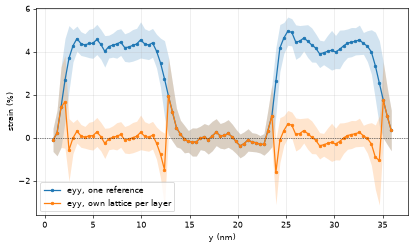

In [11]:
# Assign each column to a layer from the row-averaged eyy profile: a column
# belongs to a bright (expanded) layer where the profile exceeds half of its
# maximum, i.e. the interfaces are placed at half height.
prof = profiles["Method 2 eyy"]
ok = np.isfinite(prof["mean"])
row_eyy = np.interp(pos[:, 1], prof["center"][ok], prof["mean"][ok])
in_bright = row_eyy > 0.5 * np.nanmax(prof["mean"])

bright_ref = pm.fit_reference_lattice(graph, in_bright & pm.in_rectangle(pos, (100, 1000), (120, 300)))
per_column = np.where(in_bright[:, None, None], bright_ref.vectors, reference.vectors)
tensor_own = pm.tensor_strain(graph, per_column, mask=pm.inside_image(pos, image.shape, 20))
own = pm.binned_profile(pos, tensor_own.eyy, axis="y", bin_width=band)
plotting.plot_profiles({"eyy, one reference": profiles["Method 2 eyy"],
                        "eyy, own lattice per layer": own}, sampling=sampling);

## 8. Export per-column values

In [12]:
from pathlib import Path

Path("output").mkdir(exist_ok=True)
table = np.column_stack([pos, tensor.exx, tensor.eyy, tensor.exy, tensor.omega, m1.strain])
np.savetxt("output/superlattice_strain.csv", table, delimiter=",", fmt="%.6g",
           header="x_px,y_px,exx,eyy,exy,omega_rad,eps_method1", comments="")